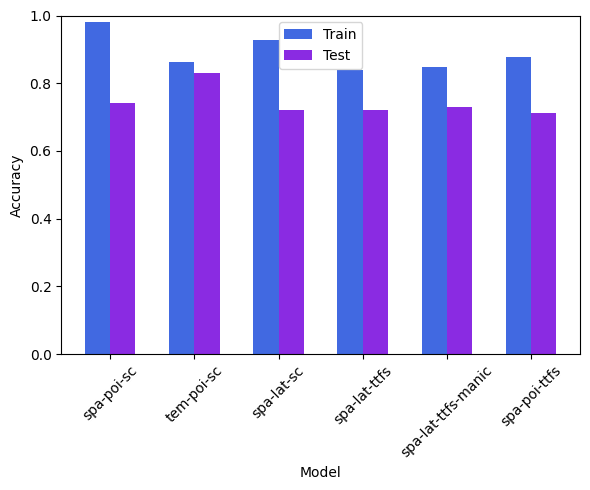

Model	Train	Test
spa-poi-sc	0.9821	0.7415
tem-poi-sc	0.8631	0.8312
spa-lat-sc	0.9268	0.7209
spa-lat-ttfs	0.8390	0.7223
spa-lat-ttfs-manic	0.8483	0.7309
spa-poi-ttfs	0.8762	0.7132


In [4]:
import json
import matplotlib.pyplot as plt
from pathlib import Path
from glob import glob
import numpy as np

from viz_util import colors, ModelNameConvention

files = sorted(glob('../output_results/E_sent/main/*.json'))
if not files:
    raise FileNotFoundError('No matching files found')

file_labels = []
train_accuracies = []
test_accuracies = []
for file_path in files:
    with open(file_path, 'r', encoding='utf-8') as file:
        data = json.load(file)

    file_name = Path(file_path).name
    file_label = '_'.join([data.get('training_config', {}).get('input_mode'), data.get('training_config', {}).get('output_file_prefix') or 'poisson_sc'])
    file_label = ModelNameConvention(file_label)
    file_labels.append(file_label)
    train_accuracies.append(data['results']['epoch_train_accuracy'][-1])
    test_accuracies.append(data['results']['test_accuracy'])

x = np.arange(len(files))
width = 0.3

fig, ax = plt.subplots(figsize=(6, 5))
ax.bar(x - width / 2, train_accuracies, width, label='Train', color=colors.train_accuracy)
ax.bar(x + width / 2, test_accuracies, width, label='Test', color=colors.test_accuracy)
ax.set_xlabel('Model')
ax.set_ylabel('Accuracy')
ax.set_ylim(0, 1)
ax.set_xticks(x)
ax.set_xticklabels(file_labels, rotation=45)
ax.legend()
plt.tight_layout()
plt.show()

out_dir = Path(files[0]).parent / "eval"
out_dir.mkdir(exist_ok=True)
with open(out_dir / 'accuracies.tsv', 'w', encoding='utf-8') as summary_file:
     summary_file.write('Model\tTrain accuracy\tTest accuracy\n')
     for label, train_accuracy, test_accuracy in zip(file_labels, train_accuracies, test_accuracies):
         summary_file.write(f'{label}\t{train_accuracy*100:.2f}\t{test_accuracy*100:.2f}\n')

print('Model\tTrain\tTest')
for label, train_accuracy, test_accuracy in zip(file_labels, train_accuracies, test_accuracies):
    print(f'{label}\t{train_accuracy:.4f}\t{test_accuracy:.4f}')

Found existing F:\KU\Thesis\Project\Code\output_results\E_sent\main\eval\energies.tsv, loading results from it.


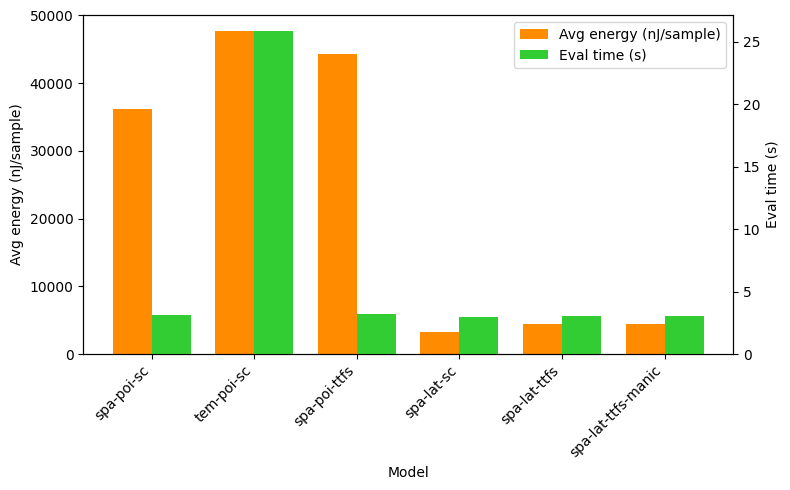

Model	Avg energy (nJ/sample)	Eval time (s)
spa-poi-sc	36192.82	3.11
tem-poi-sc	47674.76	25.83
spa-poi-ttfs	44248.14	3.17
spa-lat-sc	3271.41	2.95
spa-lat-ttfs	4401.48	3.02
spa-lat-ttfs-manic	4495.25	3.07


In [4]:
from E_sent_eval import evaluate_model
from glob import glob
from pathlib import Path
import json
from argparse import Namespace
import os

import matplotlib.pyplot as plt
import numpy as np
from viz_util import colors, ModelNameConvention

tsv_out_dir = (Path.cwd() / '..' / 'output_results' / 'E_sent' / 'main' / 'eval').resolve()
tsv_out_dir.mkdir(exist_ok=True)
energies_tsv = tsv_out_dir / 'energies.tsv'

labels = []
avg_energy_nj_per_sample = []
eval_time_s = []

if os.path.exists(energies_tsv):
    print(f"Found existing {energies_tsv}, loading results from it.")
    
    with open(energies_tsv, 'r', encoding='utf-8') as summary_file:
        next(summary_file)  # Skip header
        for line in summary_file:
            label, energy_str, time_str = line.strip().split('\t')
            labels.append(label)
            avg_energy_nj_per_sample.append(float(energy_str))
            eval_time_s.append(float(time_str))
else:
    print(f"No existing {energies_tsv} found, evaluating models from scratch.")
    models = sorted(glob('../output_results/E_sent/main/*.pt'))

    for model_path in models:
        meta_path = Path(model_path).with_suffix('.json')
        meta = json.loads(meta_path.read_text()).get('training_config', {})
        args = Namespace(**(meta | {
            "model_path": model_path,
            "diagnose": False,
            # "diagnose": True,
            # "limit": 10,
            "limit": None,
            "split": "test",
            "estimate_energy": True,
            "energy_ac_cost_pj": 25.63,
            "output_json": None,
        }))
        # Try to cast each number-like argument to int if possible, since JSON doesn't distinguish.
        args = Namespace(**{k: (int(v) if isinstance(v, str) and v.isdigit() else v) for k, v in vars(args).items()})
        
        label_name = '_'.join([meta.get('input_mode'), meta.get('output_file_prefix') or 'poisson_sc'])
        label_name = ModelNameConvention(label_name)
        labels.append(label_name)
        args.output_json = Path(model_path).parent / "eval" / f"eval_{Path(model_path).stem}.json"

        print(model_path)
        results = evaluate_model(args)

        # Convert pJ/sample to nJ/sample and ms to s immediately after evaluation.
        energy_nj_per_sample = results['avg_energy_pj_per_sample'] / 1000.0
        eval_seconds = results.get('eval_time_ms', 0) / 1000.0

        
        avg_energy_nj_per_sample.append(energy_nj_per_sample)
        eval_time_s.append(eval_seconds)
        print(eval_seconds)

positions = np.arange(len(labels))
width = 0.38

fig, ax1 = plt.subplots(figsize=(max(8, len(labels) * 1.2), 5))
ax2 = ax1.twinx()

bars_energy = ax1.bar(positions - width/2, avg_energy_nj_per_sample, width, color=colors.energy, label='Avg energy (nJ/sample)')
bars_time = ax2.bar(positions + width/2, eval_time_s, width, color=colors.time, label='Eval time (s)')

ax1.set_xlabel('Model')
ax1.set_ylabel('Avg energy (nJ/sample)')
ax2.set_ylabel('Eval time (s)')
ax1.set_xticks(positions)
ax1.set_xticklabels(labels, rotation=45, ha='right')
ax1.tick_params(axis='y')
ax2.tick_params(axis='y')

h1, l1 = ax1.get_legend_handles_labels()
h2, l2 = ax2.get_legend_handles_labels()
ax1.legend(h1 + h2, l1 + l2, loc='upper right')

plt.tight_layout()
plt.show()

with open(energies_tsv, 'w', encoding='utf-8') as summary_file:
     summary_file.write('Model\tEnergy (nJ/sample)\tEvaluation time (s)\n')
     for label, energy_value, time_value in zip(labels, avg_energy_nj_per_sample, eval_time_s):
         summary_file.write(f'{label}\t{energy_value:.2f}\t{time_value:.2f}\n')

print('Model\tAvg energy (nJ/sample)\tEval time (s)')
for label, energy_value, time_value in zip(labels, avg_energy_nj_per_sample, eval_time_s):
    print(f'{label}\t{energy_value:.2f}\t{time_value:.2f}')

spa-poi-sc ../output_results/E_sent/main\input_mode_2026-04-30_07-27-12_e-50_s-30_spatial.pt


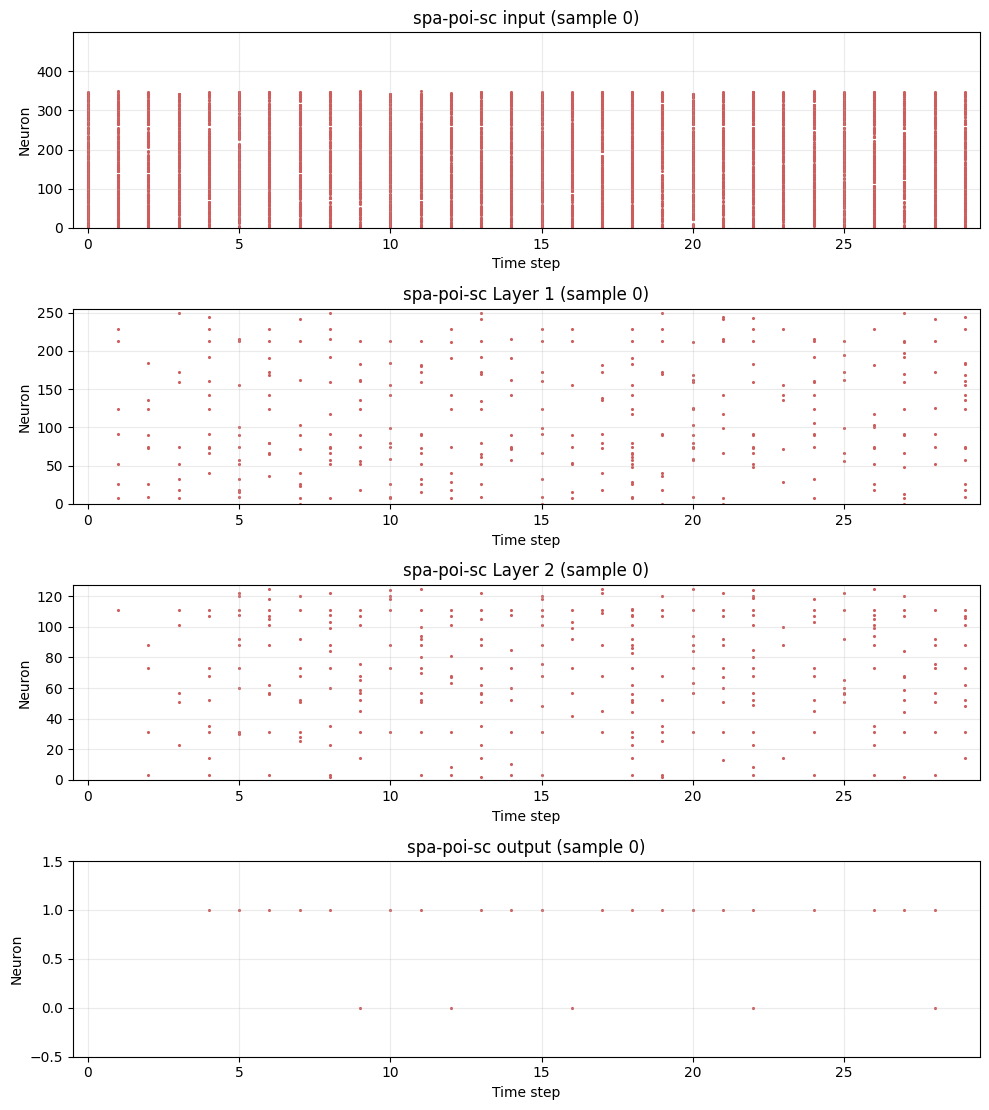

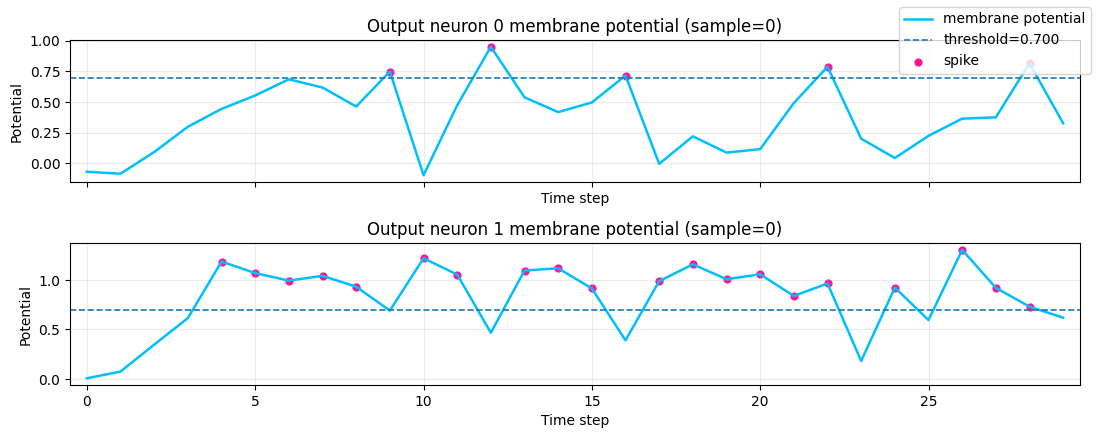

tem-poi-sc ../output_results/E_sent/main\input_mode_2026-04-30_14-46-14_e-50_s-30_temporal.pt


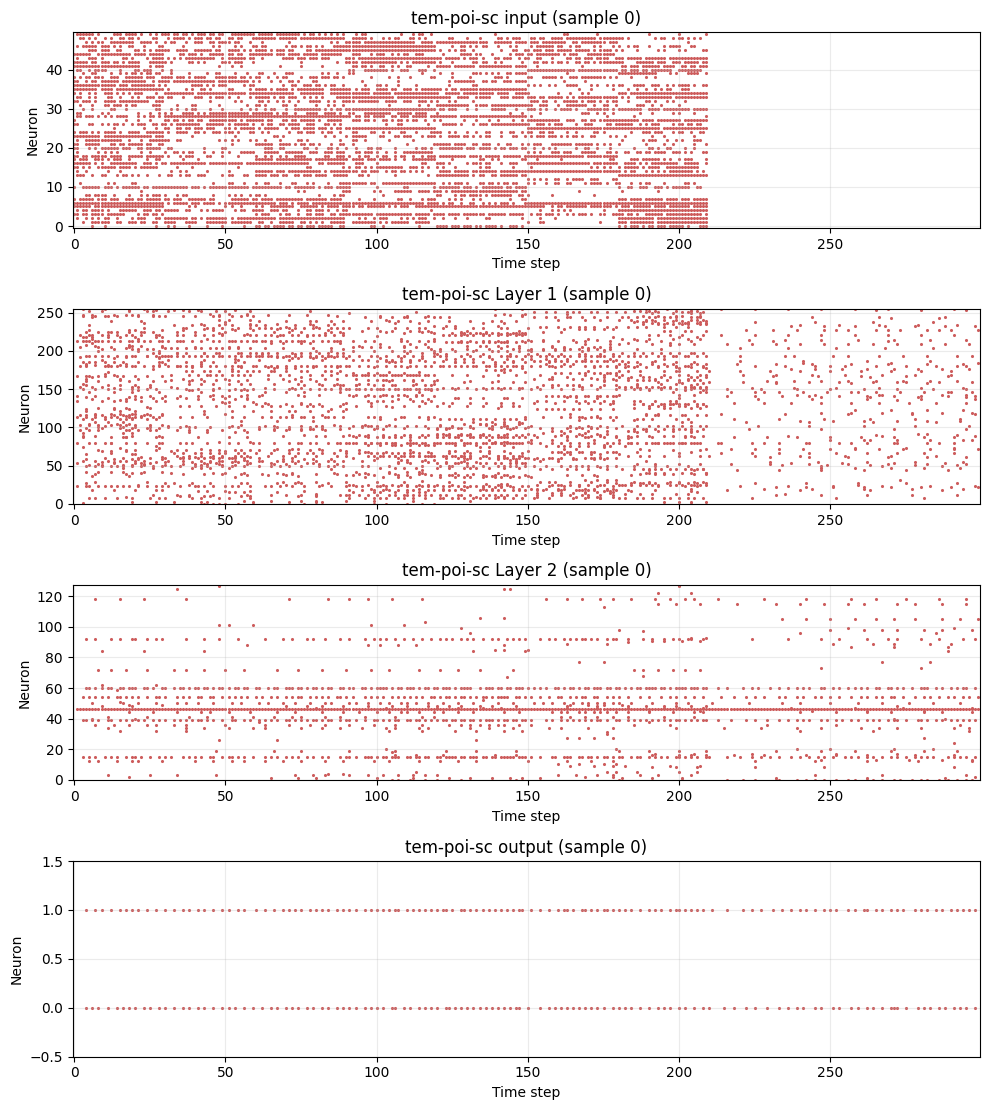

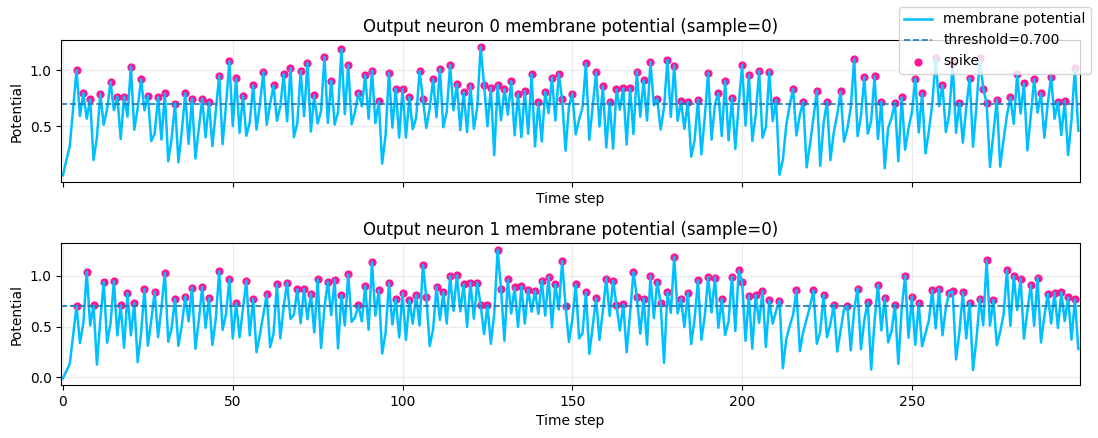

spa-lat-sc ../output_results/E_sent/main\lat_sc_2026-04-30_08-23-34_e-50_s-30_spatial.pt


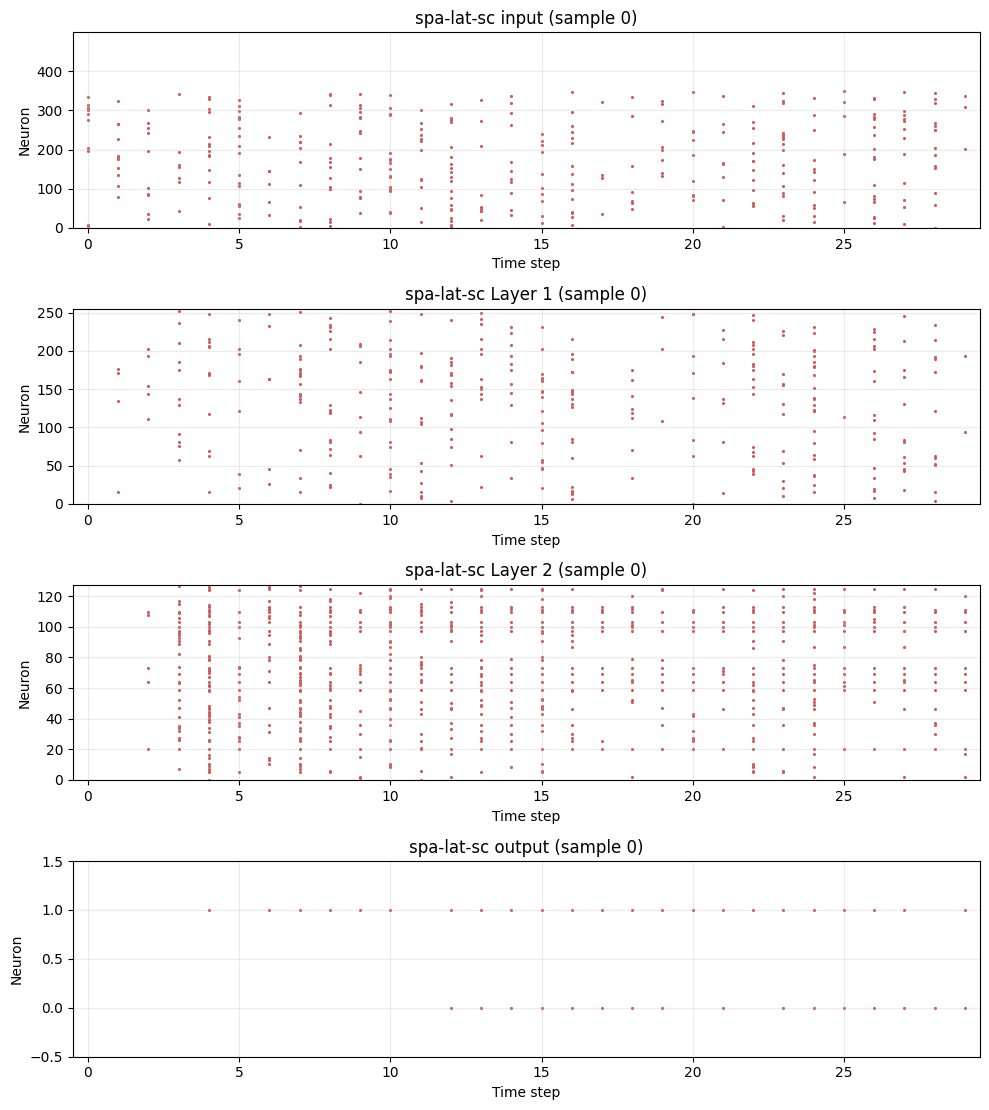

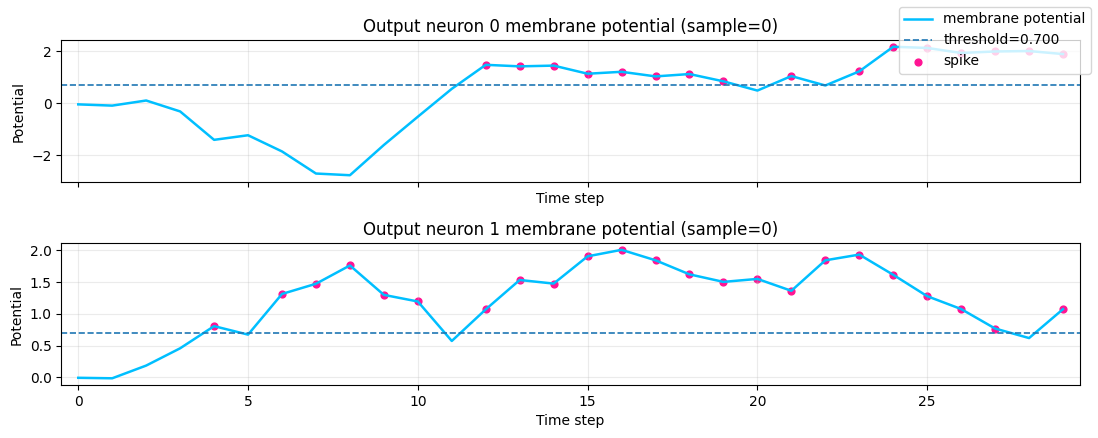

spa-lat-ttfs ../output_results/E_sent/main\lat_ttfs_ce_2026-04-30_09-18-51_e-50_s-30_spatial.pt


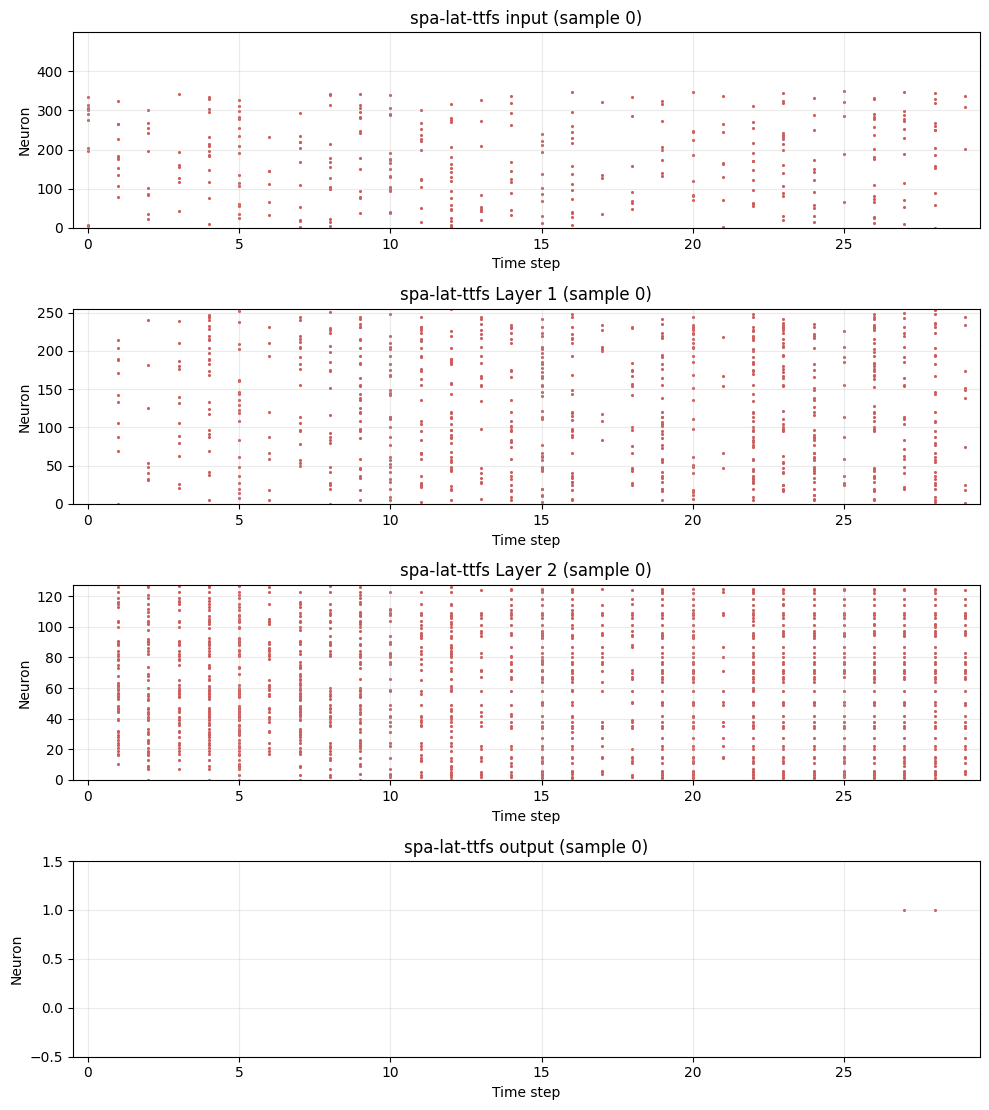

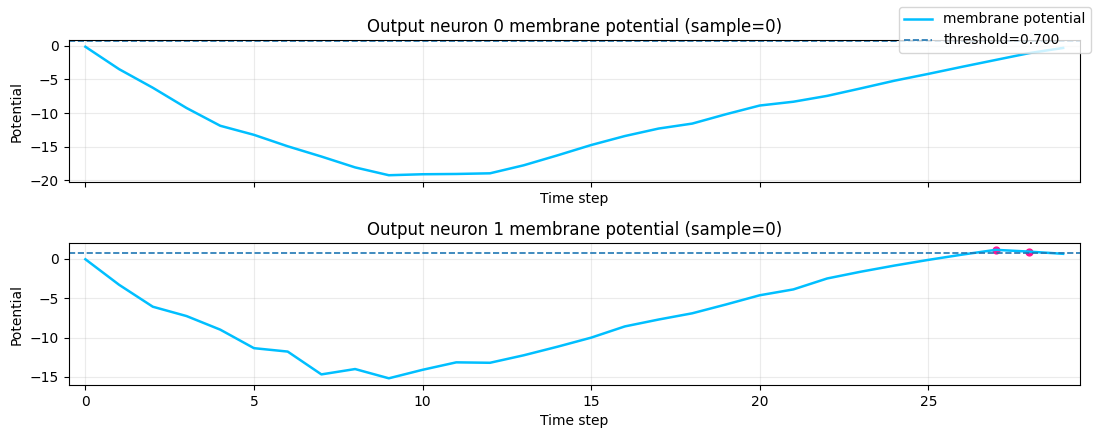

spa-lat-ttfs-manic ../output_results/E_sent/main\lat_ttfs_ce_manic_2026-05-06_18-35-07_e-50_s-30_spatial.pt


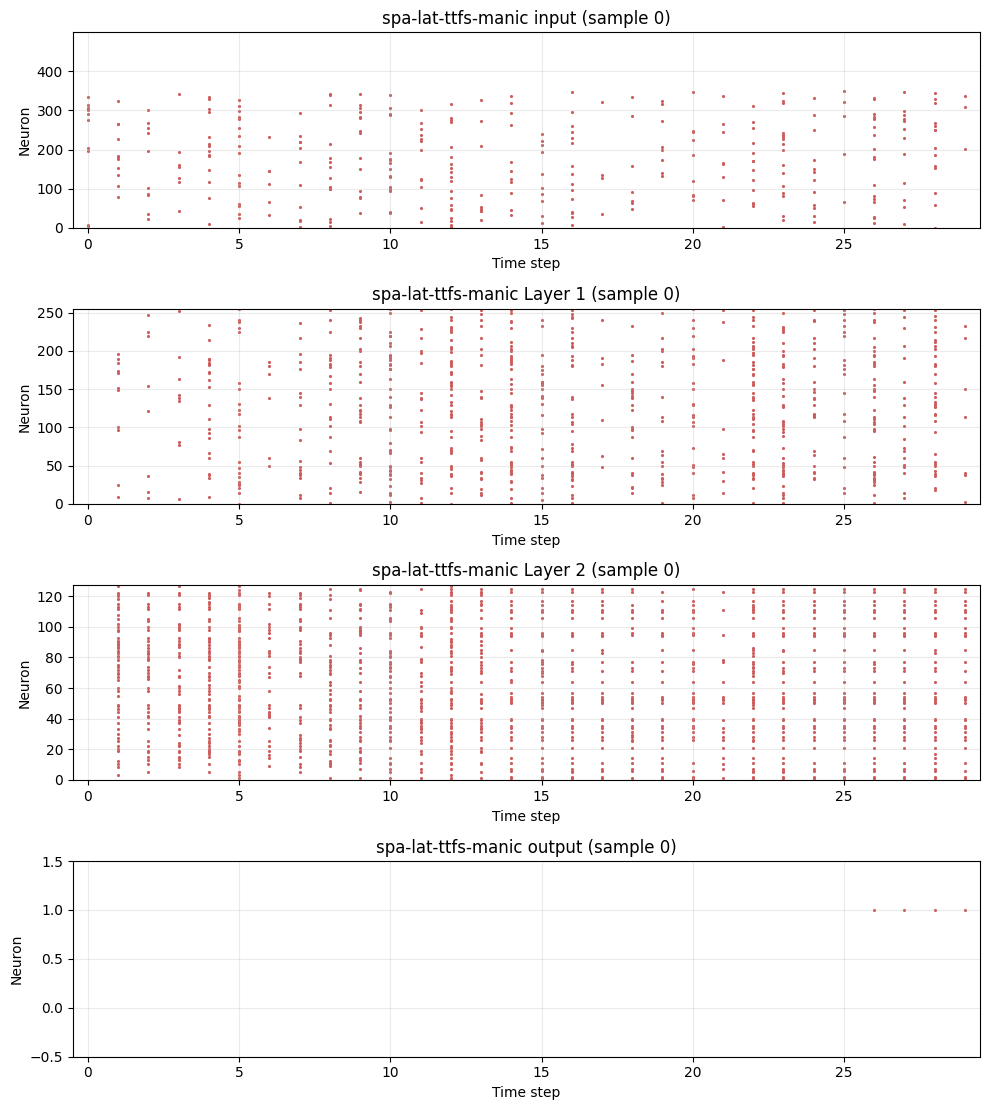

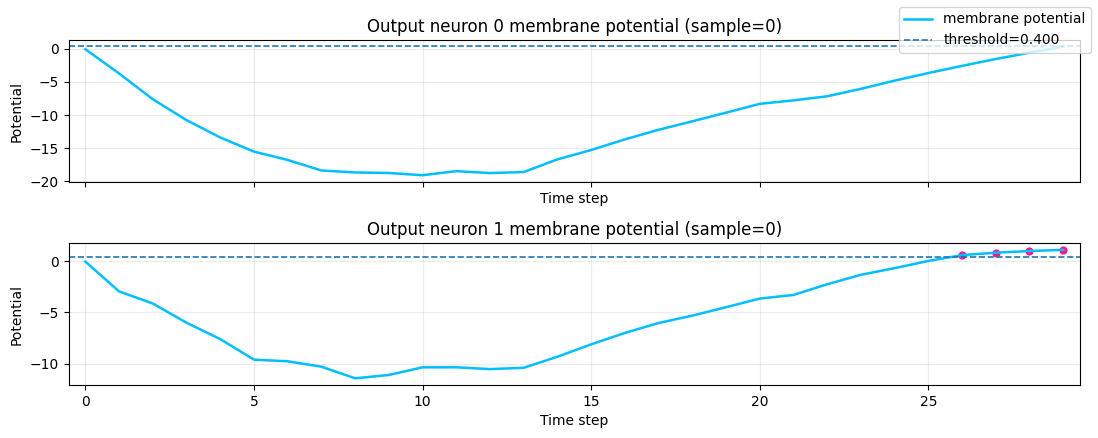

spa-poi-ttfs ../output_results/E_sent/main\poi_ttfs_ce_2026-05-10_13-31-58_e-50_s-30_spatial.pt


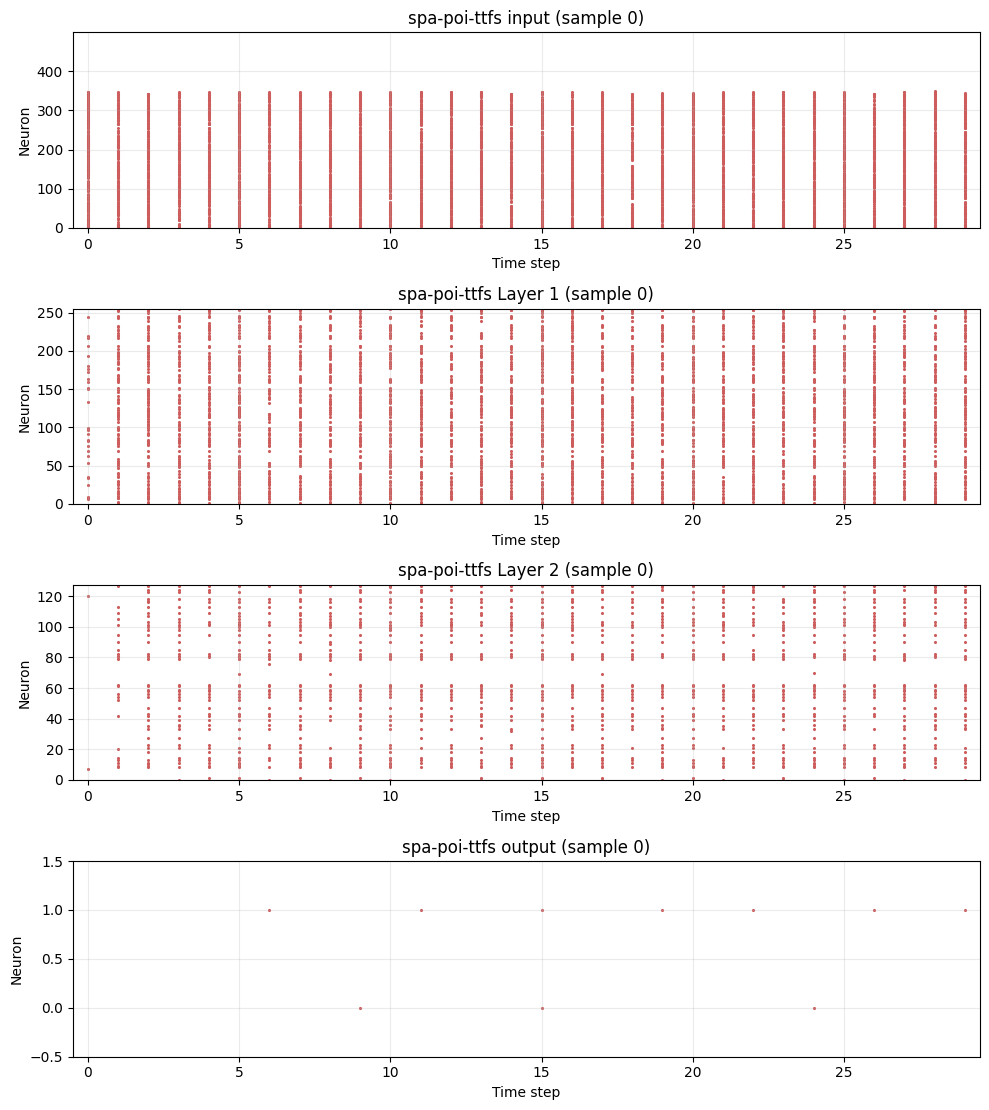

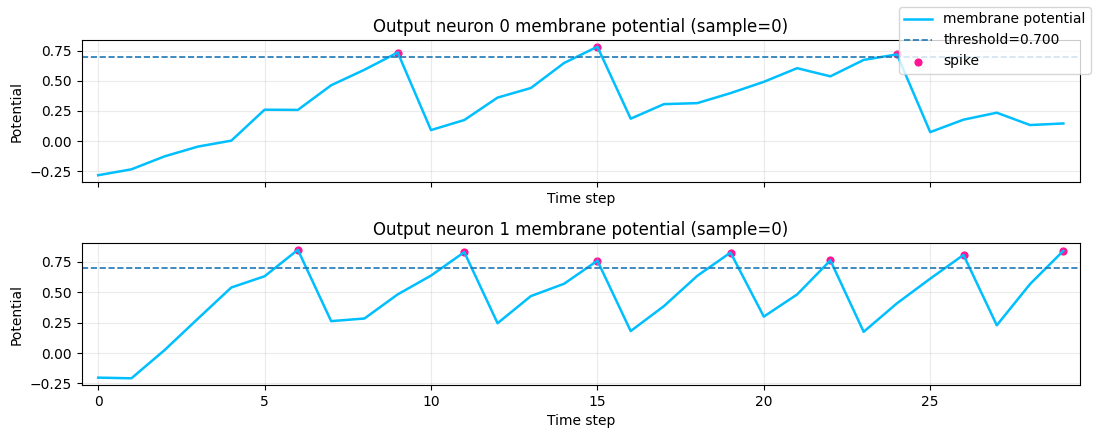

In [2]:
# diagnose plots
from E_sent_eval import evaluate_model
from glob import glob
from pathlib import Path
import json
from argparse import Namespace

import matplotlib.pyplot as plt
import numpy as np
from viz_util import colors, ModelNameConvention

models = sorted(glob('../output_results/E_sent/main/*.pt'))

labels = []
avg_energy_nj_per_sample = []
eval_time_s = []

for model_path in models:
    meta_path = Path(model_path).with_suffix('.json')
    meta = json.loads(meta_path.read_text()).get('training_config', {})
    args = Namespace(**(meta | {
        "model_path": model_path,
        # "diagnose": False,
        "diagnose": True,
        "limit": 1,
        # "limit": None,
        "split": "test",
        # "estimate_energy": True,
        # "energy_ac_cost_pj": 25.63,
        "output_json": None,
    }))
    # Try to cast each number-like argument to int if possible, since JSON doesn't distinguish.
    args = Namespace(**{k: (int(v) if isinstance(v, str) and v.isdigit() else v) for k, v in vars(args).items()})
    
    label_name = '_'.join([meta.get('input_mode'), meta.get('output_file_prefix') or 'poisson_sc'])
    label_name = ModelNameConvention(label_name)
    args.diagnose_title = label_name

    print(label_name, model_path)
    evaluate_model(args)

    # break

../output_results/E_sent/main\lat_ttfs_ce_2026-04-30_09-18-51_e-50_s-30_spatial.json
../output_results/E_sent/main\lat_ttfs_ce_manic_2026-05-06_18-35-07_e-50_s-30_spatial.json
../output_results/E_sent/main\poi_ttfs_ce_2026-05-10_13-31-58_e-50_s-30_spatial.json


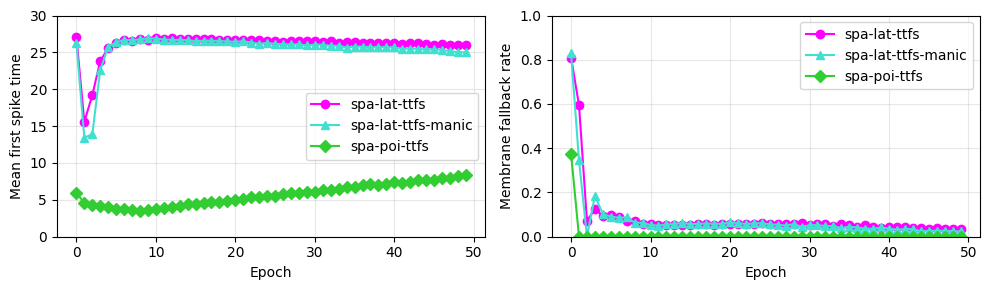

In [4]:
from glob import glob
from pathlib import Path
import json
import os

import matplotlib.pyplot as plt
import numpy as np
from viz_util import colors, ModelNameConvention

files = sorted(glob('../output_results/E_sent/main/*_ttfs_*.json'))

labels = []
mean_first_spike_times = []
fallback_rates = []

# Load all data
for file_path in files:
    with open(file_path, 'r', encoding='utf-8') as f:
        data = json.load(f)
    
    meta = data.get('training_config', {})
    label_name = '_'.join([meta.get('input_mode'), meta.get('output_file_prefix') or 'poisson_sc'])
    label_name = ModelNameConvention(label_name)
    labels.append(label_name)
    
    mean_first_spike_times.append(data['results']['epoch_ttfs_mean_first_spike_time'])
    fallback_rates.append(data['results']['epoch_ttfs_fallback_rate'])
    print(file_path)

# Create plots
markers = ['o', '^', 'D', 'v', '*', 'p', 'h', '+', 'x']
colors_list = [colors.first_mean_time, colors.fallback, colors.time]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 3))

# Plot mean first spike time
for i, (label, data) in enumerate(zip(labels, mean_first_spike_times)):
    ax1.plot(range(len(data)), data, marker=markers[i % len(markers)], 
             color=colors_list[i], label=label)

ax1.set_xlabel('Epoch')
ax1.set_ylabel('Mean first spike time')
ax1.set_ylim(0, 30)
ax1.legend()
ax1.grid(True, alpha=0.3)

# Plot fallback rate
for i, (label, data) in enumerate(zip(labels, fallback_rates)):
    ax2.plot(range(len(data)), data, marker=markers[i % len(markers)], 
             color=colors_list[i], label=label)

ax2.set_xlabel('Epoch')
ax2.set_ylabel('Membrane fallback rate')
ax2.set_ylim(0, 1)
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

../output_results/E_sent/main\lat_ttfs_ce_2026-04-30_09-18-51_e-50_s-30_spatial.json
../output_results/E_sent/main\lat_ttfs_ce_manic_2026-05-06_18-35-07_e-50_s-30_spatial.json
../output_results/E_sent/main\poi_ttfs_ce_2026-05-10_13-31-58_e-50_s-30_spatial.json


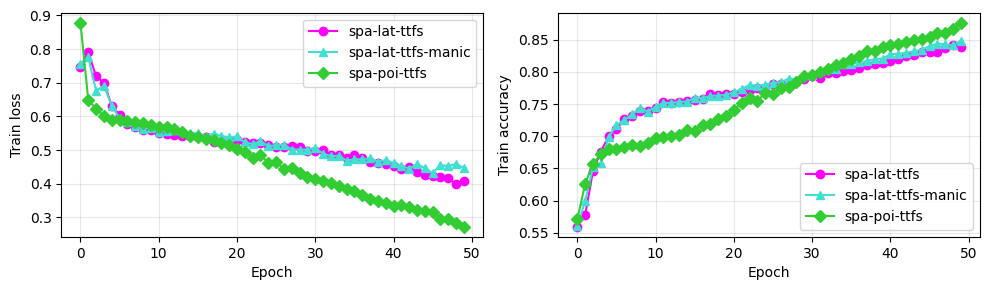

In [7]:
from glob import glob
from pathlib import Path
import json
import os

import matplotlib.pyplot as plt
import numpy as np
from viz_util import colors, ModelNameConvention

files = sorted(glob('../output_results/E_sent/main/*_ttfs_*.json'))

labels = []
x1 = []
x2 = []

# Load all data
for file_path in files:
    with open(file_path, 'r', encoding='utf-8') as f:
        data = json.load(f)
    
    meta = data.get('training_config', {})
    label_name = '_'.join([meta.get('input_mode'), meta.get('output_file_prefix') or 'poisson_sc'])
    label_name = ModelNameConvention(label_name)
    labels.append(label_name)
    
    x1.append(data['results']['epoch_train_loss'])
    x2.append(data['results']['epoch_train_accuracy'])
    print(file_path)

# Create plots
markers = ['o', '^', 'D']
colors_list = [colors.first_mean_time, colors.fallback, colors.time]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 3))

# Plot mean first spike time
for i, (label, data) in enumerate(zip(labels, x1)):
    ax1.plot(range(len(data)), data, marker=markers[i % len(markers)], 
             color=colors_list[i], label=label)

ax1.set_xlabel('Epoch')
ax1.set_ylabel('Train loss')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Plot fallback rate
for i, (label, data) in enumerate(zip(labels, x2)):
    ax2.plot(range(len(data)), data, marker=markers[i % len(markers)], 
             color=colors_list[i], label=label)

ax2.set_xlabel('Epoch')
ax2.set_ylabel('Train accuracy')
ax2.legend(loc='lower right')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()